In [ ]:
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity
from numba import cuda, float32
import math

In [ ]:
class TransformerBase(nn.Module):
    def __init__(self, vocab_size=1000, d_model=512, n_heads=4, d_ff=512 * 4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.n_heads = n_heads
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        raise NotImplementedError()

In [ ]:
class CpuPipeline(TransformerBase):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def forward(self, x):
        # x: [N]
        # ['heelo', 'im' , 'a', 'dog']
        with record_function("1_embedding"):
            x = self.embedding(x) # [N, D]

        B, N, D = x.shape

        q = self.q_proj(x)  #  [x(N, D) . Wq(D, k)] -> [N, k]
        k = self.k_proj(x)  # [N, k] -> kT []
        v = self.v_proj(x)  # [N, k]

        with record_function("2_attention_total"):

            with record_function("2a_qk_matmul"):
                attn_scores = torch.matmul(q, k.transpose(-2, -1)) / D ** 0.5

            # x: N N

            with record_function("2b_softmax"):
                attn_weights = torch.softmax(attn_scores, dim=-1)

            with record_function("2c_value_weighted_sum"):
                attn_out = torch.matmul(attn_weights, v)

        x = self.norm1(x + attn_out)

        with record_function("3_ffn"):
            ffn_out = self.ffn(x)
            x = self.norm2(x + ffn_out)

        return x

In [ ]:
@cuda.jit
def _matmul(A, B, C):
    i, j = cuda.grid(2)
    if i < C.shape[0] and j < C.shape[1]:
        tmp = float32(0.)
        for k in range(A.shape[1]):
            tmp += A[i, k] * B[k, j]
        C[i, j] = tmp

In [ ]:
@cuda.jit
def _scale(x, num):
    i, j = cuda.grid(2)
    if i < x.shape[0] and j < x.shape[1]:
        x[i, j] /= num

In [ ]:
@cuda.jit
def _softmax(input, out):
    i = cuda.grid(1)
    if i < input.shape[0]:
        # row max for numerical stability (avoid exp overflow)
        m = input[i, 0]
        for j in range(input.shape[1]):
            if input[i, j] > m:
                m = input[i, j]
        # denominator = sum of exp(x - m) over the row
        tmp = float32(0.)
        for j in range(input.shape[1]):
            tmp += math.exp(input[i, j] - m)
        for j in range(input.shape[1]):
            out[i, j] = math.exp(input[i, j] - m) / tmp

In [ ]:
class GpuV1(TransformerBase):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def forward(self, x):
        # x: [N]
        # ['heelo', 'im' , 'a', 'dog']
        with record_function("1_embedding"):
            x = self.embedding(x) # [N, D]

        B, N, D = x.shape

        q = self.q_proj(x).squeeze(0).cuda()  # [x(N, D) . Wq(D, N)] -> [N, N]
        k = self.k_proj(x).squeeze(0).cuda()  # [N, N] -> kT []
        v = self.v_proj(x).squeeze(0).cuda()  # [N, N]

        attn_scores = torch.empty((N, N), device=torch.device('cuda'))
        attn_weights = torch.empty((N, N), device=torch.device('cuda'))
        attn_out = torch.empty((N, N), device=torch.device('cuda'))
        with record_function("2_attention_total"):
            with record_function("2a_qk_matmul"):
                kT = k.transpose(-2, -1)
                threadsperblock = (16, 16)
                blockspergrid_x = int(math.ceil(q.shape[0] / threadsperblock[0]))
                blockspergrid_y = int(math.ceil(kT.shape[1] / threadsperblock[1]))
                blockspergrid = (blockspergrid_x, blockspergrid_y)

                _matmul[blockspergrid, threadsperblock](q, kT, attn_scores)
                # x [N N]

                _scale[blockspergrid, threadsperblock](attn_scores, D ** 0.5)

            with record_function("2b_softmax"):
                tpb = 256
                bpg = int(math.ceil(attn_scores.shape[0] / tpb))
                _softmax[bpg, tpb](attn_scores, attn_weights)

            with record_function("2c_value_weighted_sum"):
                tpb = (16, 16)
                bpg_x = int(math.ceil(attn_weights.shape[0] / tpb[0]))
                bpg_y = int(math.ceil(v.shape[1] / tpb[1]))
                _matmul[(bpg_x, bpg_y), tpb](attn_weights, v, attn_out)

        attn_out = attn_out.to(torch.device('cpu'))
        x = self.norm1(x + attn_out)

        with record_function("3_ffn"):
            ffn_out = self.ffn(x)
            x = self.norm2(x + ffn_out)

        return x


In [ ]:
class GpuV2(TransformerBase):
    pass

In [ ]:
class GpuV3(TransformerBase):
    pass

USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:37 51333:51333 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-09 16:03:38 51333:51333 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-09 16:03:38 51333:51333 

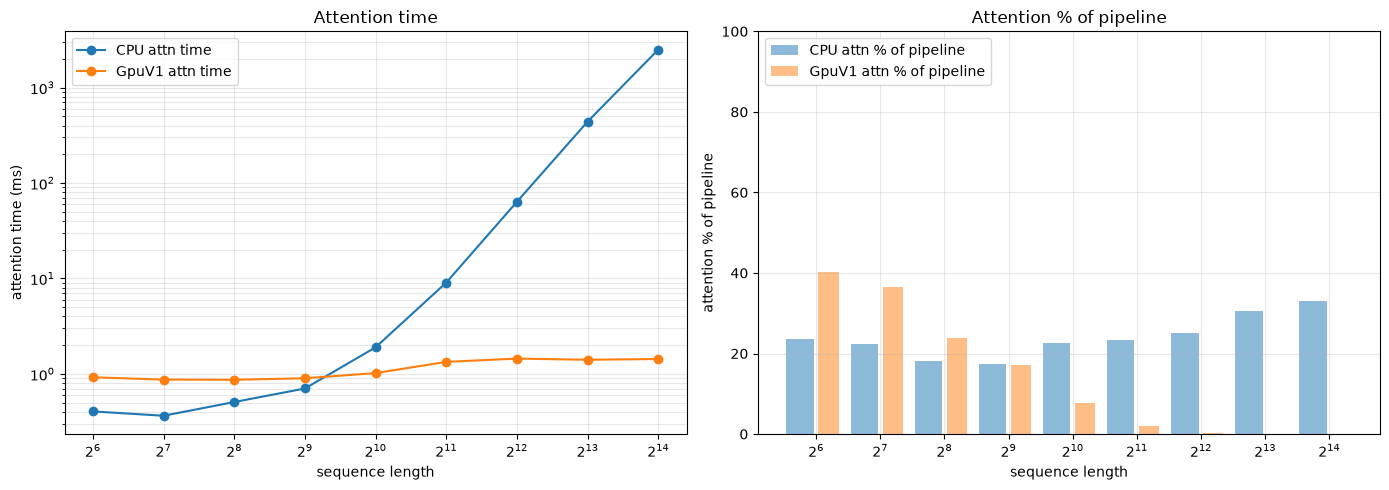

In [50]:
import matplotlib.pyplot as plt

start, end = 6, 15
seq_lens = [2 ** x for x in range(start, end)]
def plot_cpu_vs_gpu(seq_lens=seq_lens, repeats=3):
    # ponytail: d_model=n because GpuV1 assumes D == N (attn_out is [N, N])
    def bench_attention(cls, n):
        model = cls(d_model=n).eval()
        x = torch.randint(0, 1000, (1, n))
        with torch.no_grad():
            model(x)  # warmup (numba JIT on first GpuV1 call)
            with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
                with record_function("total"):
                    for _ in range(repeats):
                        model(x)
                    torch.cuda.synchronize()
        # ponytail: a key can appear twice (CPU-side + CUDA-side event) -> take max over duplicates;
        # device_time for GPU kernels (async, invisible to cpu_time), cpu_time otherwise
        def t(key):
            return max(max(e.cpu_time_total, e.device_time_total)
                       for e in prof.key_averages() if e.key == key)
        attn, total = t("2_attention_total"), t("total")
        return attn / repeats / 1e6, 100 * attn / total  # (seconds, % of pipeline)

    cpu = [bench_attention(CpuPipeline, n) for n in seq_lens]
    gpu = [bench_attention(GpuV1, n) for n in seq_lens]
    cpu_t, cpu_pct = zip(*cpu)
    gpu_t, gpu_pct = zip(*gpu)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # graph 1 lines: attention time
    ax1.plot(seq_lens, [t * 1e3 for t in cpu_t], marker='o', color='tab:blue', label='CPU attn time')
    ax1.plot(seq_lens, [t * 1e3 for t in gpu_t], marker='o', color='tab:orange', label='GpuV1 attn time')
    ax1.set_xscale('log', base=2); ax1.set_yscale('log')
    ax1.set_xlabel('sequence length'); ax1.set_ylabel('attention time (ms)')
    ax1.set_title('Attention time')
    ax1.grid(True, which='both', alpha=0.3)
    ax1.legend(loc='upper left')

    # graph 2 bars: % of pipeline spent in attention (multiplicative offsets since x is log2)
    ax2.bar([n * 0.85 for n in seq_lens], cpu_pct, width=[n * 0.25 for n in seq_lens],
            alpha=0.5, color='tab:blue', label='CPU attn % of pipeline')
    ax2.bar([n * 1.15 for n in seq_lens], gpu_pct, width=[n * 0.25 for n in seq_lens],
            alpha=0.5, color='tab:orange', label='GpuV1 attn % of pipeline')
    ax2.set_xscale('log', base=2)
    ax2.set_xlabel('sequence length'); ax2.set_ylabel('attention % of pipeline')
    ax2.set_ylim(0, 100)
    ax2.set_title('Attention % of pipeline')
    ax2.grid(True, which='both', alpha=0.3)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_cpu_vs_gpu()